# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [ ]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

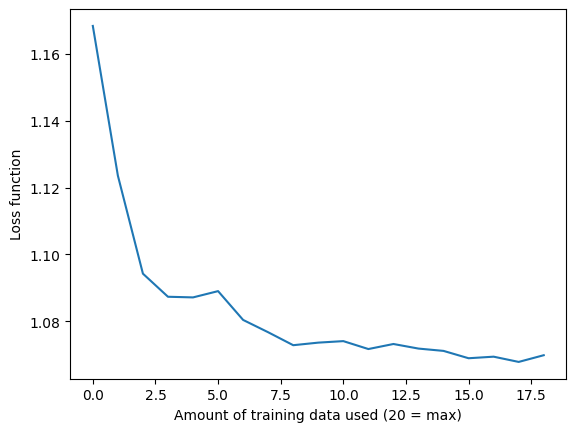

In [13]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [14]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

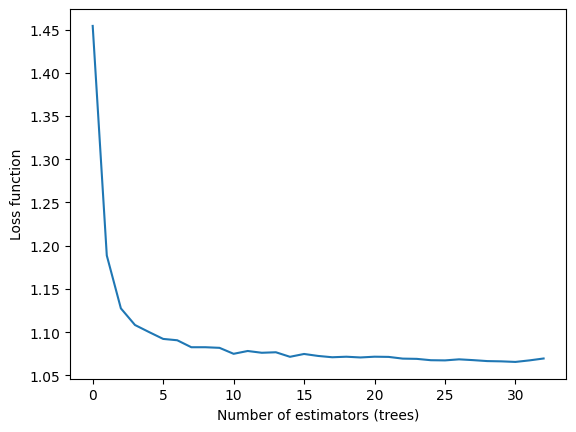

In [15]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

The training data size plot is more interesting because it shows how model performance improves with more data, reflecting learning capability. The number of estimators plot shows minor RMSE fluctuations, offering less insight into model behavior.
- Training data size directly impacts fraud detection, where sufficient data is critical for capturing rare fraud patterns. Number of estimators is a secondary hyperparameter with diminishing returns beyond a threshold.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Random Forest Performance:
F1-Score: 0.9175
ROC-AUC: 0.9144


/tmp/ipykernel_13747/2793897332.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')


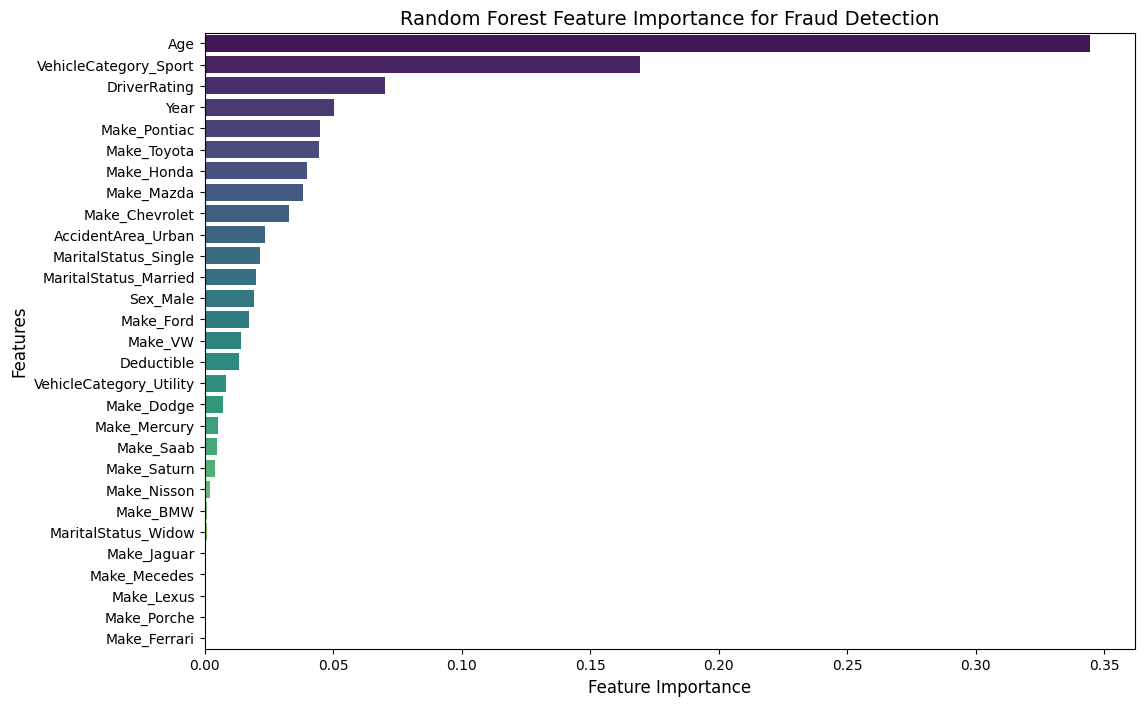

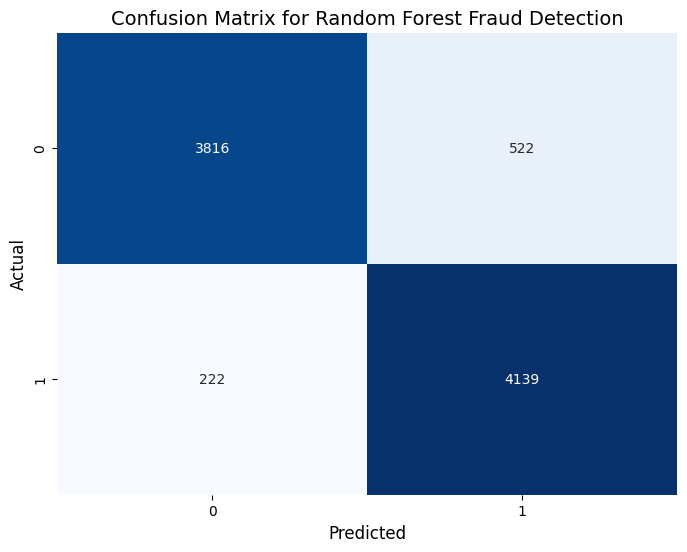

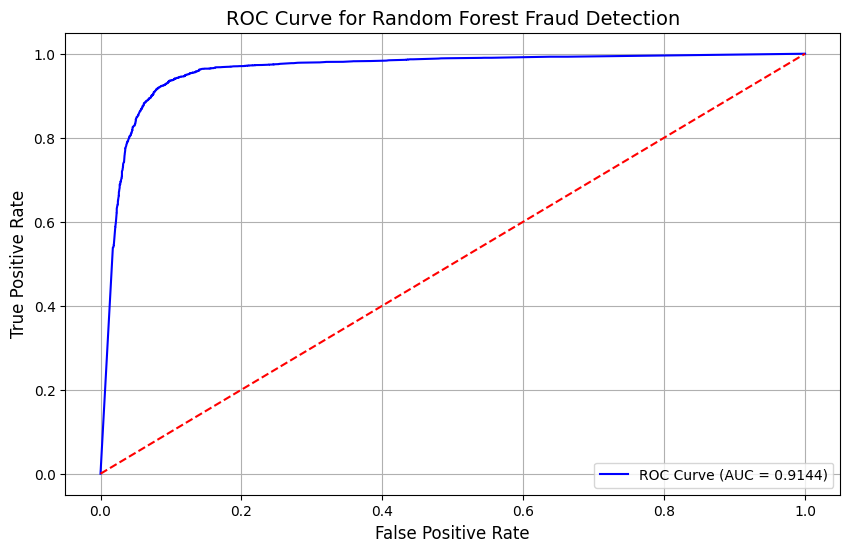


Best Parameters from GridSearchCV:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best F1-Score: 0.9209

Best Model Performance:
F1-Score: 0.9193
ROC-AUC: 0.9168


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import os
import kagglehub

data_path = kagglehub.dataset_download("khusheekapoor/vehicle-insurance-fraud-detection")
file = os.path.join(data_path, "carclaims.csv")
df = pd.read_csv(file)

# Preprocessing
df["FraudFound_Numeric"] = df["FraudFound"].map({"No": 0, "Yes": 1})
categorical_cols = ["Sex", "MaritalStatus", "Make", "VehicleCategory", "AccidentArea"]
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
numeric_cols = ["Age", "Deductible", "DriverRating", "Year"]
df_features = df[numeric_cols].join(df_encoded)
X = df_features
y = df["FraudFound_Numeric"]

# Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predictions and Metrics
y_pred = rf.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print("\nRandom Forest Performance:")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Feature Importance Plot
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Random Forest Feature Importance for Fraud Detection", fontsize=14)
plt.savefig("feature_importance_week11.png", dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix for Random Forest Fraud Detection", fontsize=14)
plt.savefig("confusion_matrix_week11.png", dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve for Random Forest Fraud Detection", fontsize=14)
plt.legend()
plt.grid(True)
plt.savefig("roc_curve_week11.png", dpi=300, bbox_inches='tight')
plt.show()

# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print("\nBest Parameters from GridSearchCV:")
print(rf_grid.best_params_)
print(f"Best F1-Score: {rf_grid.best_score_:.4f}")

# Evaluate Best Model
best_rf = rf_grid.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_best)
print("\nBest Model Performance:")
print(f"F1-Score: {f1_best:.4f}")
print(f"ROC-AUC: {roc_auc_best:.4f}")


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

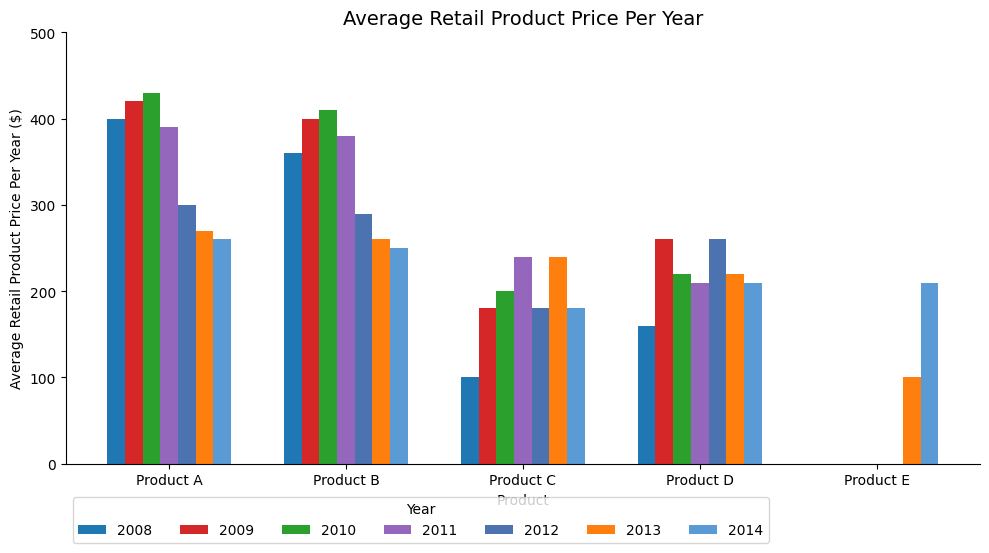

In [3]:
import matplotlib.pyplot as plt



products = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014]
prices = np.array([
    [400, 420, 430, 390, 300, 270, 260],  # Product A
    [360, 400, 410, 380, 290, 260, 250],  # Product B
    [100, 180, 200, 240, 180, 240, 180],  # Product C
    [160, 260, 220, 210, 260, 220, 210],  # Product D
    [0, 0, 0, 0, 0, 100, 210]             # Product E (assuming 0 for years with no data)
])


n_products = len(products)
n_years = len(years)

bar_width = 0.1
index = np.arange(n_products)
colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#4c72b0', '#ff7f0e', '#5b9bd5']

fig, ax = plt.subplots(figsize=(10, 6))

for i, year in enumerate(years):
    ax.bar(index + i * bar_width, prices[:, i], bar_width, label=str(year), color=colors[i])

ax.set_xlabel('Product')
ax.set_ylabel('Average Retail Product Price Per Year ($)')
ax.set_title('Average Retail Product Price Per Year', fontsize=14)
ax.set_xticks(index + (n_years * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(products)
ax.set_yticks(np.arange(0, 550, 100))
ax.set_ylim(0, 500)
ax.legend(title='Year', loc='lower left', bbox_to_anchor=(0, -0.2), ncol=n_years)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()